# Consensus clustering


This notebook demonstrates how to perform consensus clustering using TOAD. After running TOAD on multiple input clusters—such as different variables, models, configurations, or ensemble members—this module enables you to identify regions that are consistently detected across those inputs.

**How it works (in brief):**

1. Build a spacetime neighbour graph on your grid; optionally **dilate shift-event labels** in time and space so slightly misaligned shift detections can still “vote” together (`temporal_tolerance`, `spatial_tolerance`).
2. For each neighbour link, keep it if the **fraction of input clusterings** that support it is at least **`min_consensus`**.
3. **Connected components** of the surviving links become consensus regions; you can drop very small ones afterwards (`min_cluster_area`).


# Imports


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from toad import TOAD
import numpy as np

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (12, 6)

map_style = {"projection": "south_pole", "map_frame": False, "grid_lines": False}

# Prepare data

In this example, we use simulated ice-sheet data from Garbe et al. (2020) and create 20 versions of it, each with an increasing time delay (from 1 to 20 time steps). **Why delays?** Same underlying field, shifted in time—so you can see how **`temporal_tolerance`** pools or separates **shift events** when their timing differs between “models”.

This setup is a convenient toy for exploring how consensus hyperparameters behave; it is not meant to mimic a real multi-model ensemble.


In [2]:
# Helper function for delaying time series
def delay_along_time(da: xr.DataArray, delay: int, time_dim: str) -> xr.DataArray:
    """First `delay` steps = value at time 0; then original shifted by `delay`."""
    if delay <= 0:
        return da
    axis = da.get_axis_num(time_dim)
    nt = da.sizes[time_dim]
    x = np.moveaxis(np.asarray(da.values), axis, 0)
    out = np.empty_like(x)
    if delay >= nt:
        out[:] = x[0]
    else:
        out[:delay] = x[0]
        out[delay:] = x[:-delay]
    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=da.coords, dims=da.dims, attrs=da.attrs.copy())

In [3]:
td = TOAD(
    "/Users/jakobharteg/GitHub/toad/tutorials/test_data/garbe_2020_antarctica.nc",
    time_dim="GMST",
)
td.drop_shifts()
td.drop_clusters()
td.data = td.data.coarsen(x=2, y=2, boundary="trim").reduce(np.mean)

# # delay in time steps
for d in np.arange(1, 20):
    td.data[f"thk_delay_{d}"] = delay_along_time(td.data["thk"], int(d), td.time_dim)


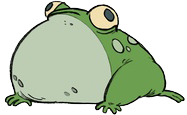

In [4]:
td

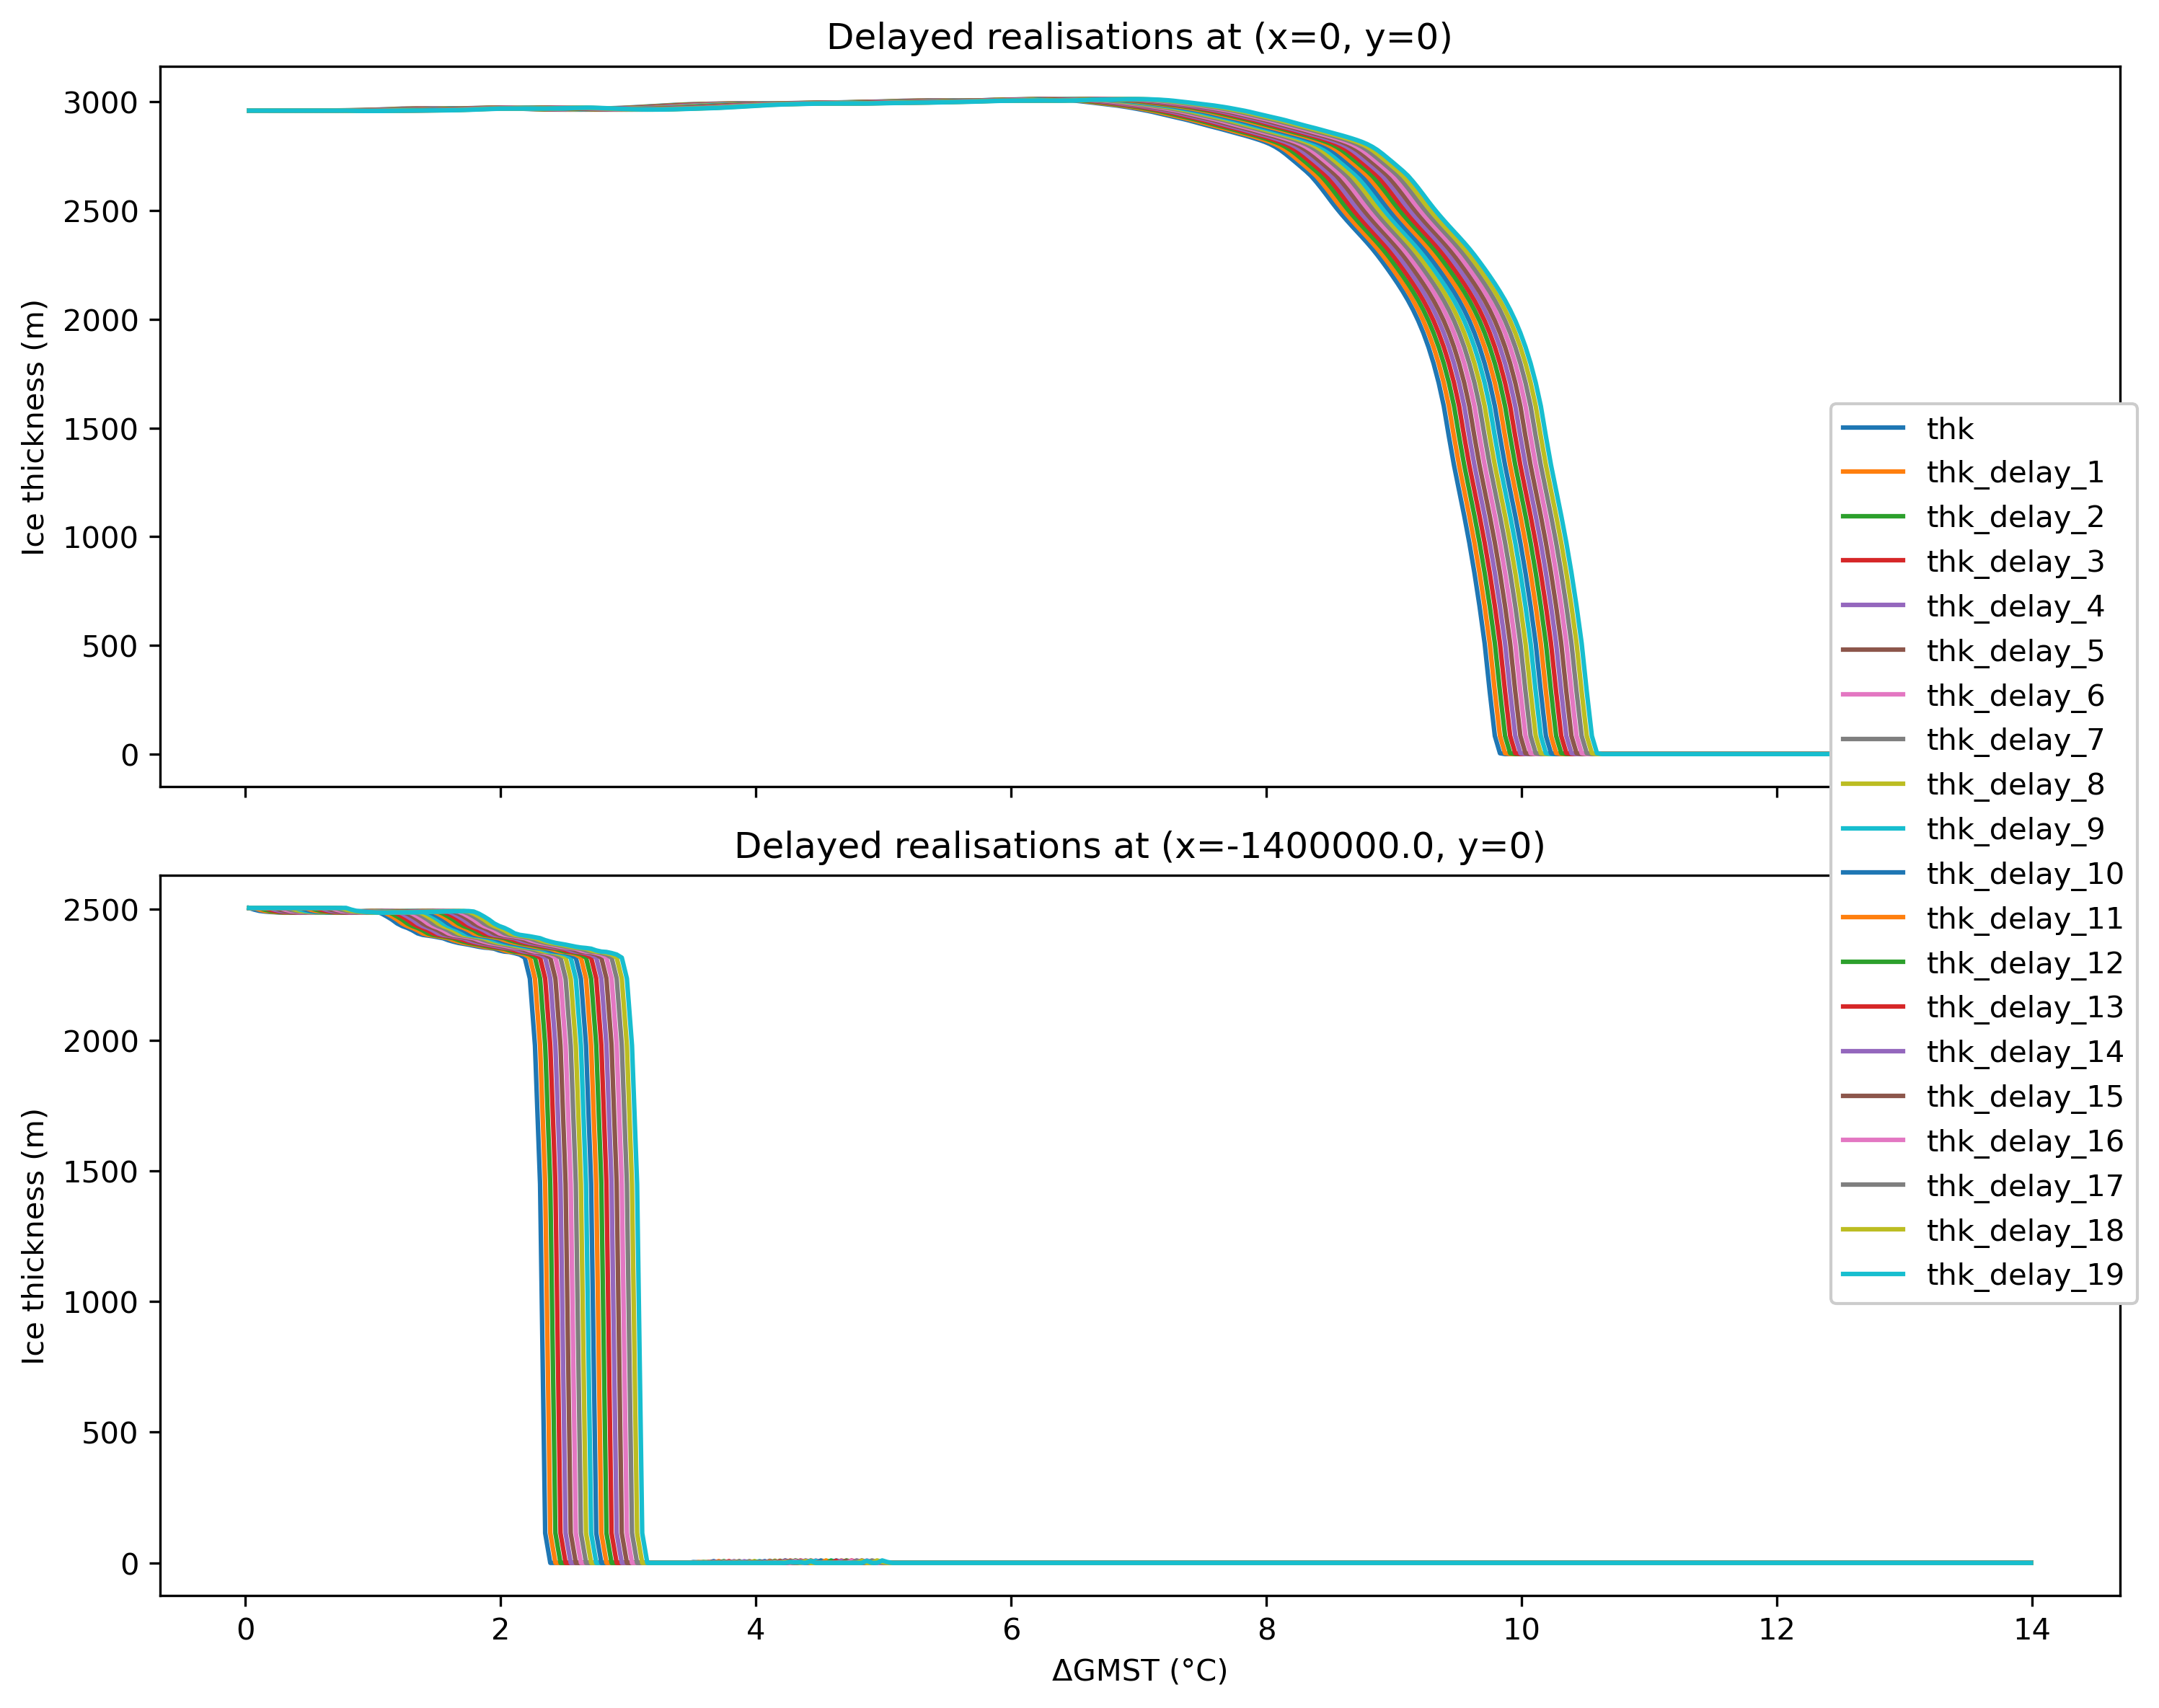

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

locations = [(0, 0), (-14e5, 0)]  # Example alternative locations, (x, y)

for idx, (x_val, y_val) in enumerate(locations):
    for var in td.base_vars:
        axs[idx].plot(
            td.data[td.time_dim],
            td.data[var].sel(x=x_val, y=y_val, method="nearest"),
            label=var,
        )
    axs[idx].set_ylabel("Ice thickness (m)")
    axs[idx].set_title(f"Delayed realisations at (x={x_val}, y={y_val})")
axs[-1].set_xlabel("ΔGMST (°C)")

# Create a common legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), framealpha=1)

plt.tight_layout()
plt.show()

# Computes shifts and clusters


In [6]:
from sklearn.cluster import HDBSCAN
from toad.shifts import ASDETECT

td.drop_shifts()
for bvar in td.base_vars:
    td.compute_shifts(
        var=bvar, method=ASDETECT(timescale=(0.5, 3.5)), show_progress=False
    )

INFO: New shifts variable thk_dts: min/mean/max=-1.000/-0.226/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_1_dts: min/mean/max=-1.000/-0.226/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_2_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_3_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_4_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_5_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_6_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0

In [7]:
td.drop_clusters()
for svar in td.shift_vars:
    td.compute_clusters(
        var=svar,
        method=HDBSCAN(min_cluster_size=10),
        overwrite=True,
        time_weight=2.0,
        shift_direction="negative",
        shift_threshold=0.5,
    )

INFO: New cluster variable thk_dts_cluster: Identified 38 clusters in 3,869 pts; Left 33.8% as noise (1,306 pts).
INFO: New cluster variable thk_delay_1_dts_cluster: Identified 39 clusters in 3,866 pts; Left 31.4% as noise (1,212 pts).
INFO: New cluster variable thk_delay_2_dts_cluster: Identified 36 clusters in 3,863 pts; Left 32.6% as noise (1,260 pts).
INFO: New cluster variable thk_delay_3_dts_cluster: Identified 39 clusters in 3,848 pts; Left 32.0% as noise (1,232 pts).
INFO: New cluster variable thk_delay_4_dts_cluster: Identified 41 clusters in 3,841 pts; Left 33.5% as noise (1,285 pts).
INFO: New cluster variable thk_delay_5_dts_cluster: Identified 39 clusters in 3,849 pts; Left 36.3% as noise (1,399 pts).
INFO: New cluster variable thk_delay_6_dts_cluster: Identified 36 clusters in 3,855 pts; Left 29.4% as noise (1,135 pts).
INFO: New cluster variable thk_delay_7_dts_cluster: Identified 37 clusters in 3,842 pts; Left 28.8% as noise (1,106 pts).
INFO: New cluster variable thk_d

# Compute consensus


#### Required params:

**`min_consensus`**

Consensus builds regions from **local links** between neighbouring spacetime grid points. Each link gets a score in \([0,1]\) measuring **how often your input clusterings support that link**. `min_consensus` is the **cut-off**: links with score **below** this value are discarded.

- **Higher** → require **stronger agreement** across inputs (often **smaller / more fragmented** regions).
- **Lower** → allow **weaker or noisier** agreement (often **larger / more merged** regions).

**`temporal_tolerance`**

Different clusterings can place the **same shift event** **one or a few timesteps apart**. Before comparing inputs, the algorithm **thickens shift-event labels** along the time axis: a label at time \(t\) is treated as active within **`±temporal_tolerance`** steps when gathering support.

- Intuition: **how much timing jitter** you are willing to **pool** when asking “do these runs agree?”
- Not the same as capping how long a final consensus region can be end-to-end: **long-lived structures can still appear via chains** of supported links.

**`spatial_tolerance`**

Similarly, runs may disagree slightly on **which grid cell** a shift is assigned to. Before voting, **shift-event labels** are **dilated in space** using **graph hops** on your spatial adjacency (native grid or HealPix neighbours when regridded).

- **`0`** → only **exactly overlapping** spatial supports count when matching.
- **Larger** → **nearby** cells can count as supporting the same structure (helps with **small spatial offsets**), but if **too large** it can **merge distinct** nearby shift events.
- **Note:** Increasing `spatial_tolerance` beyond a small value can **slow down the computation a lot**—evidence accumulation gets much more expensive as the tolerance grows.

**`min_cluster_area`** (optional post-filter)

After consensus, drops clusters whose **spatial footprint** (distinct grid cells that ever carry that cluster id) is **below** this threshold; those cells become noise (`-1`). The library default is **2** (removes single-cell clusters); the call below uses **`5`** for a stricter map. Use **`None`** to turn this filter off.


In [8]:
td.compute_consensus(
    min_consensus=0.75,  # -> 3/4 of input clusterings must agree
    temporal_tolerance=10,  # -> Allow for 10 time steps of jitter
    spatial_tolerance=0,  # -> Only exact spatial support counts
    min_cluster_area=5,  # -> Keep only consensus clusters with at least 5 grid cells
    overwrite=True,
)

spacetime consensus: 100%|██████████| 20/20 [00:12<00:00,  1.65it/s]
INFO: New consensus variable cluster_consensus: Identified 35 consensus clusters over 3,158,750 spacetime cells; 0.93% shift noise / not in consensus (29,315 cells); 98.58% no abrupt shift (3,113,889 cells NaN).


The consensus summary table shows the main properties of each detected consensus cluster:

- `mean_consistency`: How strongly inputs agree on this cluster (higher = more robust).
- `area` / `mean x/y`: Footprint and centroid location.
- `median_median_shift_time` / `std_median_shift_time`: Median of per-input spatial medians (and spread **between** input clusterings).
- `pooled_median_shift_time` / `pooled_std_shift_time`: Median and sample std of **all** transition-time samples in the long table (pooled over inputs: same as `td.plot.consensus_shift_times_violins(...)`).
- `median_std_shift_time` / `std_std_shift_time`: Typical **within-input** spread of transition times (“sharpness”) and how much that sharpness varies **between** inputs.


In [9]:
td.aggregate.consensus_summary()

,cluster_id,mean_consistency,area,mean_y,mean_x,median_median_shift_time,std_median_shift_time,median_std_shift_time,std_std_shift_time,pooled_median_shift_time,pooled_std_shift_time
0,0,0.868123,616,-3.812987e+05,1.323117e+06,8.2901,0.575826,0.739905,0.113773,8.5501,0.777461
1,1,0.863787,281,7.718149e+04,-1.147701e+06,2.5701,0.171418,0.118492,0.024667,2.5901,0.190020
2,2,0.883471,234,1.224957e+06,8.248205e+05,9.4501,0.093723,0.256919,0.043005,9.4701,0.274666
3,3,0.873781,133,1.068451e+06,-3.446616e+04,7.6901,0.131697,0.165880,0.014843,7.6701,0.204937
4,4,0.854138,169,-8.494674e+05,-2.575621e+05,1.8901,0.148677,0.175729,0.031366,1.8701,0.219549
5,5,0.843051,125,-1.689920e+06,9.673600e+05,4.2701,0.298722,0.426578,0.080089,4.2301,0.458346
6,6,0.831909,61,4.263607e+05,7.505574e+05,10.6901,0.248312,0.233142,0.068180,10.6701,0.294826
7,7,0.871449,43,-2.491163e+05,-2.014884e+05,12.4101,0.188029,0.312857,0.036720,12.4301,0.334603
8,8,0.841913,31,-1.029936e+06,-1.114581e+06,7.9901,0.208252,0.312160,0.084411,7.9901,0.338470
9,9,0.879255,28,1.850286e+06,-4.011428e+05,2.8201,0.092434,0.159441,0.062541,2.8701,0.184335


# Visualise consensus

**`consensus_overview`**: map of each consensus cluster plus a shift-time panel (default `kind=\"medians\"`; set `kind=\"violins\"` for pooled sample violins). **`consensus_timeseries`**: one consensus cluster’s aggregate behaviour against the delayed input series (here, median thickness along GMST).


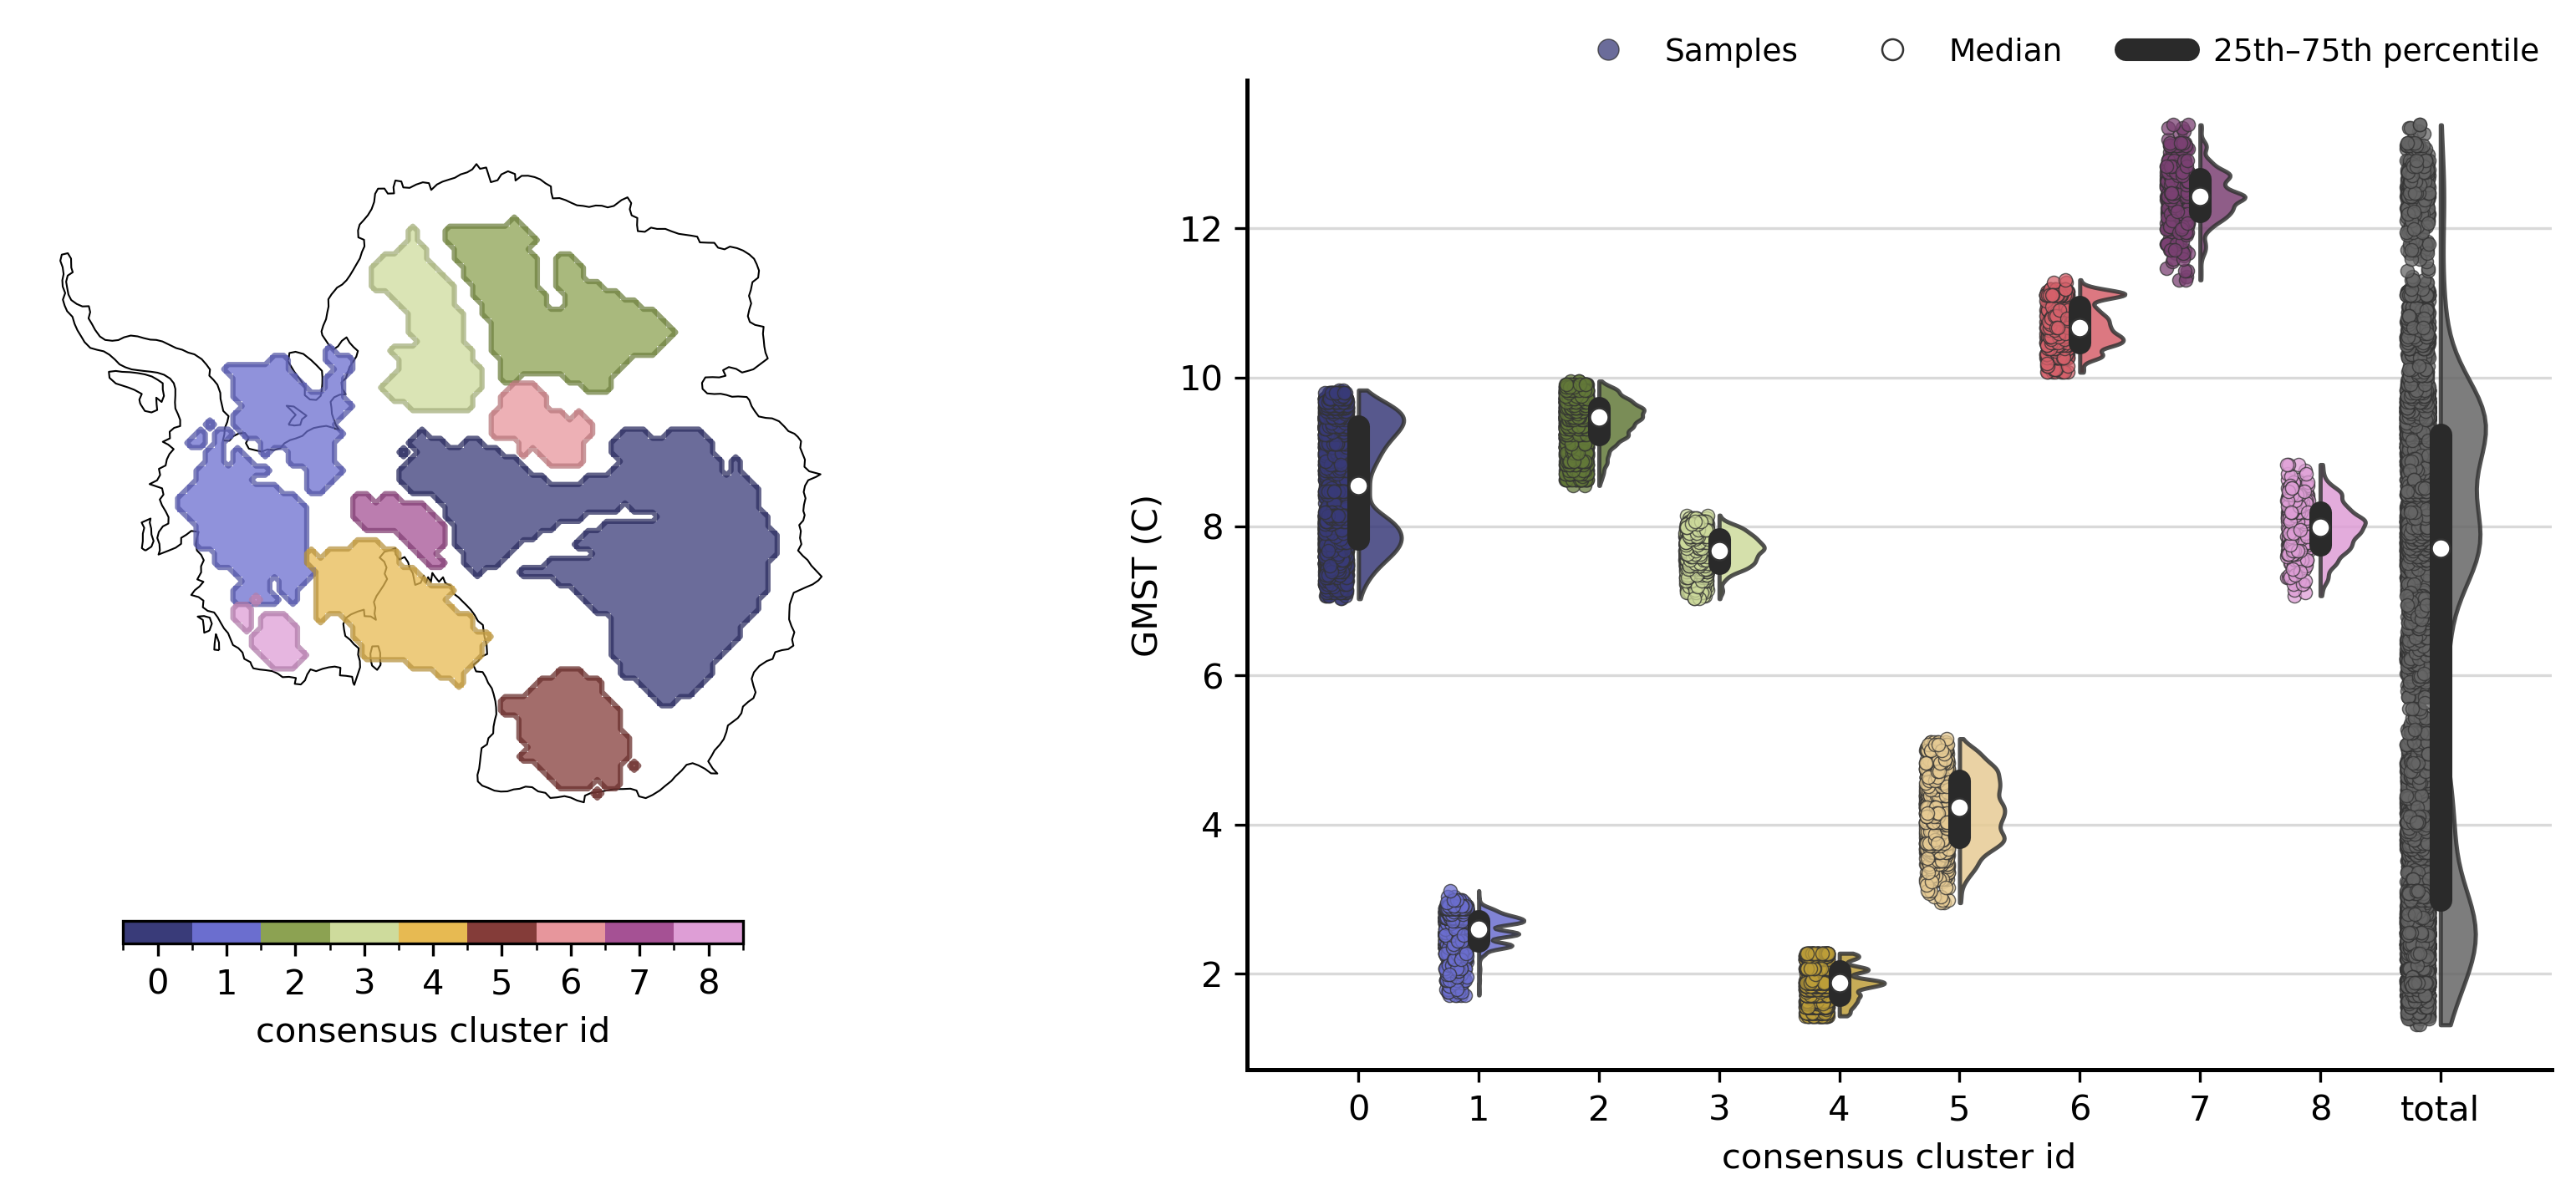

In [10]:
td.plot.consensus_overview(map_style=map_style, cluster_ids=range(9), kind="violins");


# Each can be plotted individually with:

# td.plot.consensus_shift_times_medians(...)
#     cluster_ids=range(9),
# )

# td.plot.consensus_map(
#     cluster_ids=range(8),
#     map_style=map_style,
# );

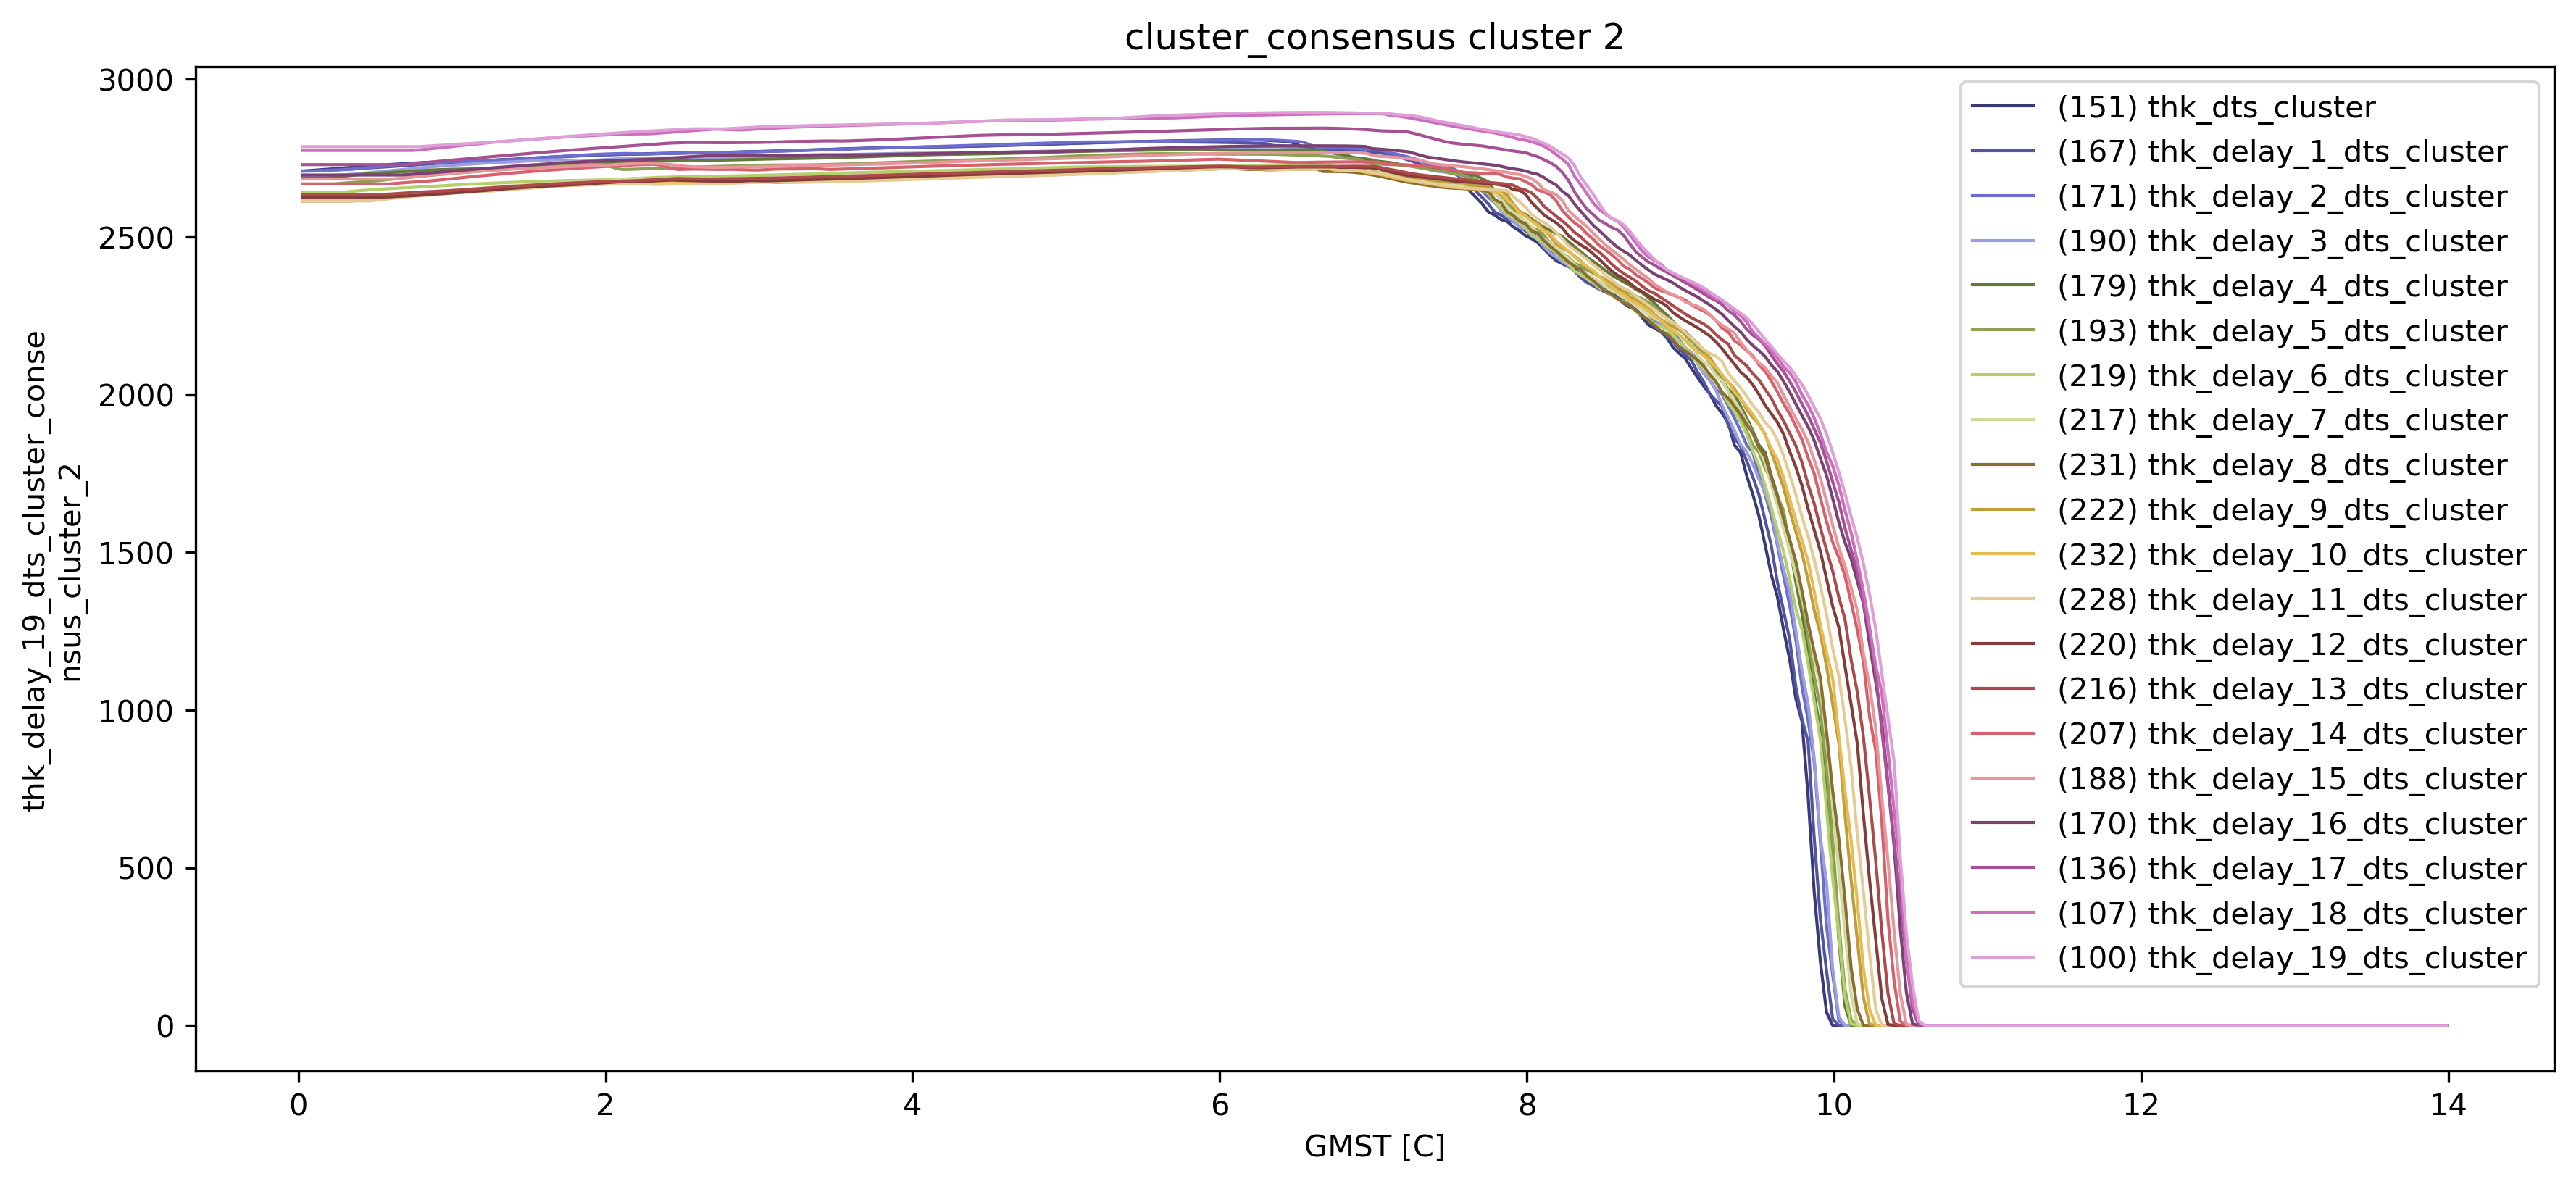

In [11]:
td.plot.consensus_timeseries(
    cluster_id=2, subplots=False, aggregation="median", figsize=(14, 6)
);

### Cluster occurrence map


A different useful aggregation plot is simply a heatmap of where clusters occur.


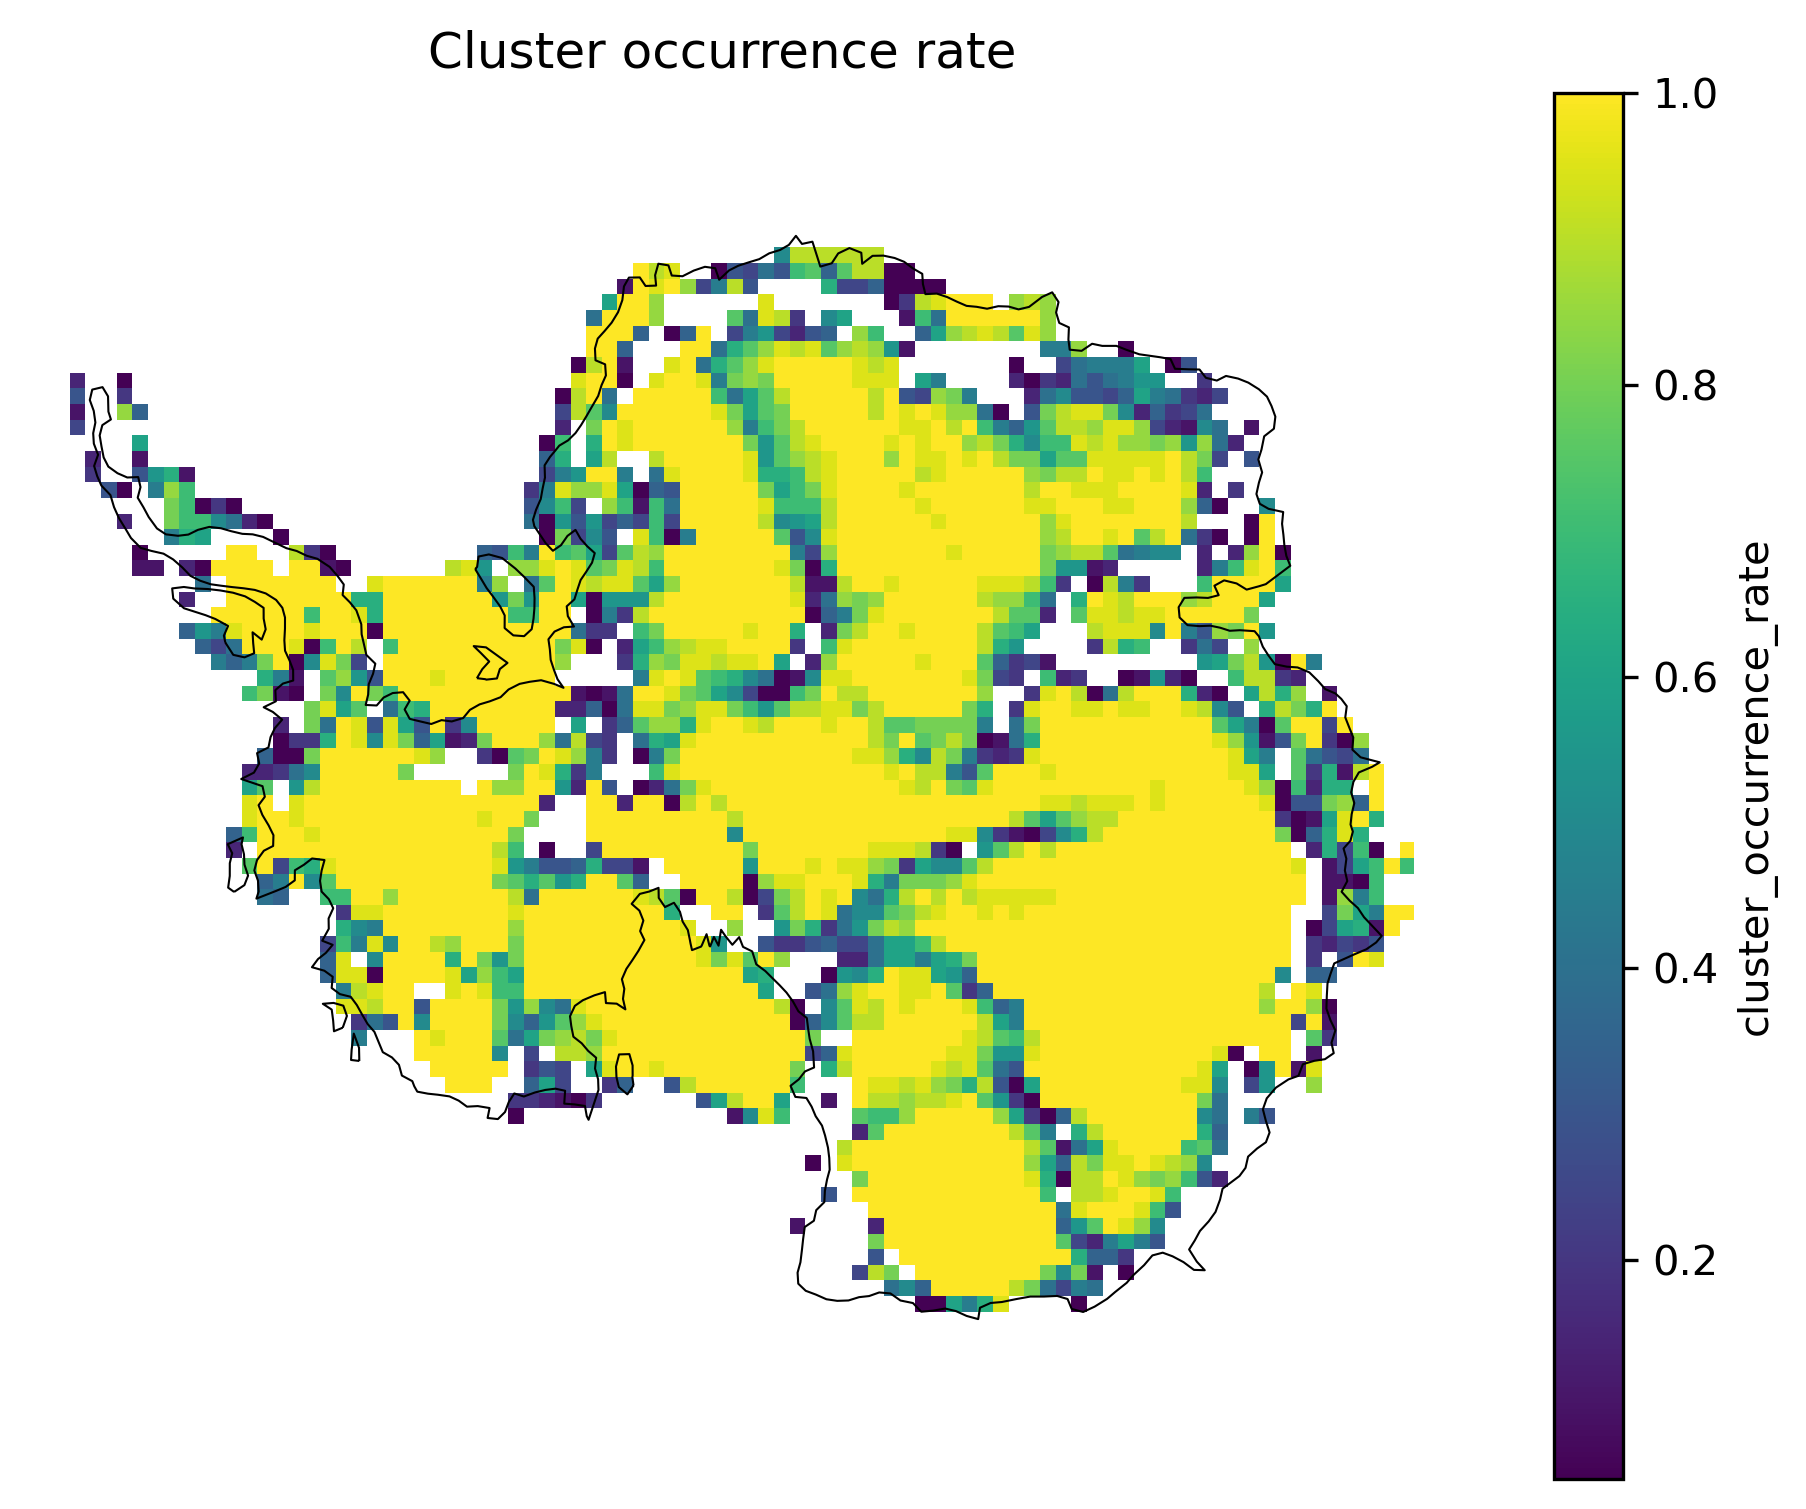

In [12]:
td.plot.cluster_occurrence_rate_map(map_style=map_style);